In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import pandas as pd
import numpy as np
from pathlib import Path
titanic_data_path = Path('/content/drive/MyDrive/machine_learning/titanic.csv')

# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

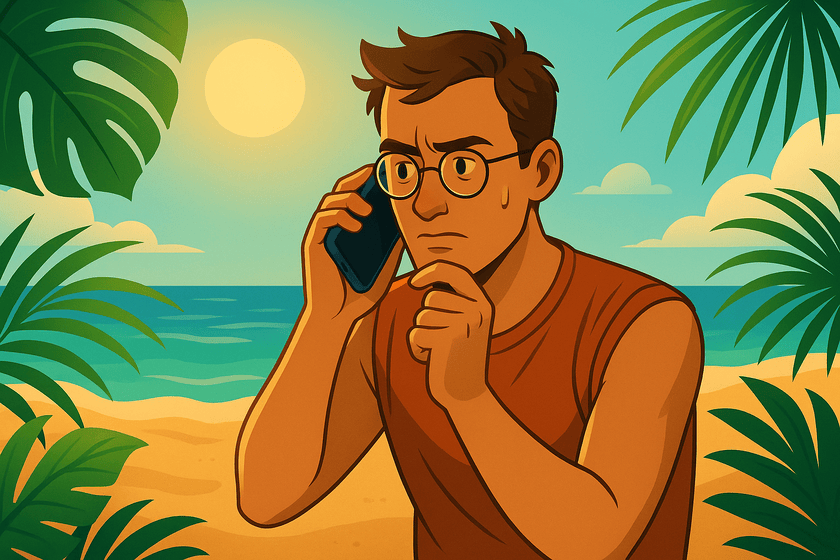

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [35]:

titanic_data = pd.read_csv(titanic_data_path)
titanic_data.shape

(891, 12)

In [36]:
titanic_data.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


In [37]:
titanic_data['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)



# Wstępna analiza zbioru danych:

In [38]:
titanic_data.head(n=10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,NaN,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [39]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         793 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [40]:
titanic_data.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,793.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,33.123938,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,51.578312,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.925000,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.500000,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN


In [41]:
titanic_data.isna().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Fare,98
Embarked,2
Name,0
Pclass,0
Survived,0
PassengerId,0
Parch,0
SibSp,0


In [42]:
titanic_data['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


**Wstępne wnioski:**

Zbiór danych ma 891 wierszy(pasażerów) i 12 kolumn.


---


**Czy wszystkie kolumny są istotne w kontekście zadania?**

W kontekście zadania kolumna 'PassengerId', które jest identyfikatorem w zbiorze, jest nam nie przydatne. Również kolumna 'Ticket' może zostać usunięta, ponieważ w zadaniu nie jest określone czy numery biletów (czy w ogóle) są zawierają w sobie dodatkowe informacje.


---
**Czy typy danych są odpowiednie do znaczenia kolumny?**

Typy danych są odpowiednie do znaczenia kolumn.

---


**Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz?**

 W kolumnach 'Cabin', 'Age' 'Fare' i 'Embarked' brakuje danych.

 W kolumnie 'Embarked' brakuje dwóch wartości.W tym przypadku uzupełnimy braki najczęstszą wartością.

 W kolumnie 'Cabin' jest wiele braków (687). Ze względu na to najlepiej będzie utworzyć sztuczną kategorię 'Unknown'. W przypadku uzupełnionych wierszy można z nich wyciągnąć pokład.


Braki w 'Age' zostaną uzupełnione medianą wieku wyznaczoną osobno dla każdej wartości 'Title', zachowa to więcej informacji niż użycie mediany globalnej.

Braki w 'Fare' zostaną uzupełnione średnią ceną biletu danej klasy 'Pclass', ponieważ można przypuścić cena biletu jest związana z klasą podróży.


---
**Która zmienna oznacza predykowaną klasę?**

Survived

---
**Wymóg zadania - dodatkowe kolumny:**
* 'Deck' na podstawie pierwszej litery z 'Cabin', opisująca pokład pasażera. Jeżeli informacja o kabinie jest niedostępna, wartość Unknown zostanie skrócona do kategorii 'U'.

* 'Title' zostanie wyciągnięty z  kolumny 'Name'

# Usunięcie niepotrzebnych kolumn, uzupełnienie brakujących wartości i dodanie nowych kolumn


In [43]:
#removing columns that are unneccessary for the task
titanic_data.drop(columns=['PassengerId','Ticket'],inplace=True)

In [44]:
#fill in the missing data
most_common_embarked = titanic_data['Embarked'].mode()[0]
titanic_data['Embarked'] = titanic_data['Embarked'].fillna(most_common_embarked)

titanic_data['Cabin'] = titanic_data['Cabin'].fillna('Unknown')

#Filling in the missing fares based on the mean of fares for each Pclass
mean_fare_by_class = titanic_data.groupby('Pclass')['Fare'].mean()
titanic_data['Fare'] = titanic_data['Fare'].fillna(titanic_data['Pclass'].map(mean_fare_by_class))

#To fill in the missing values in 'Age' first we need to seperate the 'Title' out of the 'Name' column
titanic_data['Title'] = titanic_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False) #first new column
median_age_by_title = titanic_data.groupby('Title')['Age'].median()

titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Title'].map(median_age_by_title))

In [45]:
#add Deck column
titanic_data['Deck'] = titanic_data['Cabin'].str[0]

# we got all we needed from 'Cabin' column, can remove it
#the same case for 'Name' column, we got all relevent information - Title, out of it.
titanic_data.drop(columns=['Cabin','Name'],inplace=True)

In [46]:
#clean up titles
titanic_data['Title']= titanic_data['Title'].replace({'Mlle':'Miss',"Mmme":'Mrs'})

#replace titles with less than 10 instances
title_counts = titanic_data['Title'].value_counts()
titanic_data['Title'] = titanic_data['Title'].map(lambda x: 'Other' if title_counts[x] < 10 else x)

# Wizualizacja

Sprawdzenie, które cechy mogą być związane z przeżyciem pasażera

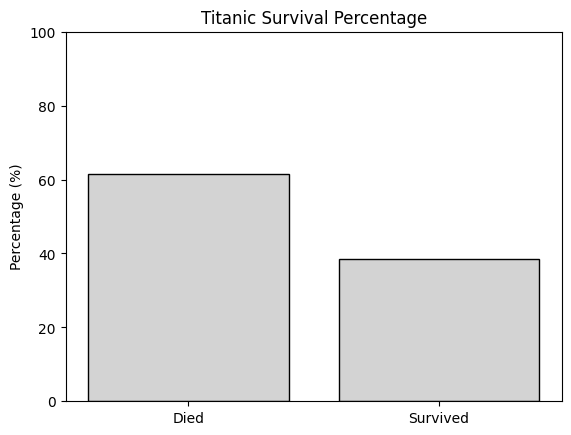

In [47]:

import matplotlib.pyplot as plt
import seaborn as sns


#basic survivability graph
survival_perc = titanic_data['Survived'].value_counts(normalize=True) * 100

plt.bar(['Died','Survived'],survival_perc,color='lightgray',edgecolor='black')
plt.ylabel('Percentage (%)')
plt.title('Titanic Survival Percentage')
plt.ylim(0, 100)
plt.show()

# Survived w zależności od wartości kategoralnych:

* Pclass
* Sex
* Embarked
* Deck
* Title

Uwaga: Dla każdej kategorii obliczany jest średni poziom Survived. Ponieważ Survived przyjmuje wartości 0 i 1, średnia pomnożona przez 100 jest
jednocześnie procentem pasażerów, którzy przeżyli w danej grupie.


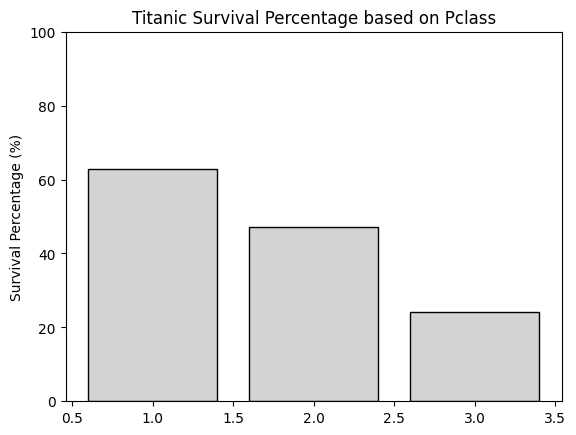

In [48]:
def plot_bar_categorical(df, column_name):
  survival_perc = df.groupby(column_name)['Survived'].mean() * 100
  plt.bar(survival_perc.index,survival_perc,color='lightgray',edgecolor='black')
  plt.ylabel('Survival Percentage (%)')
  plt.title(f'Titanic Survival Percentage based on {column_name}')
  plt.ylim(0, 100)
  plt.show()

plot_bar_categorical(titanic_data, 'Pclass')

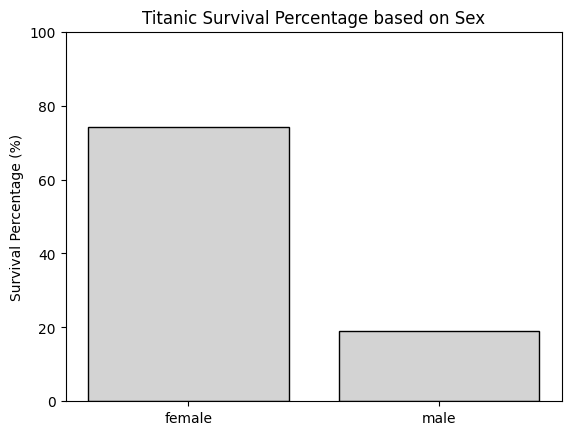

In [49]:
plot_bar_categorical(titanic_data, 'Sex')

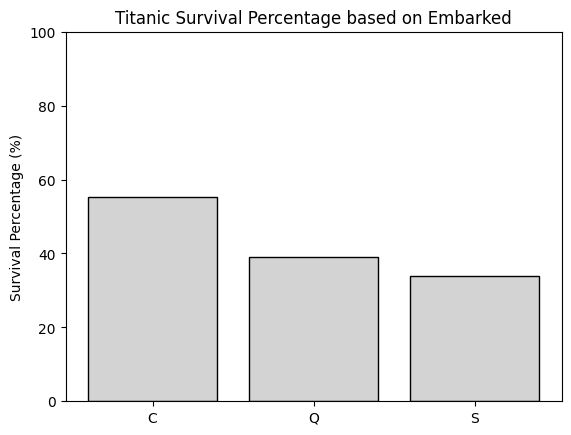

In [50]:
plot_bar_categorical(titanic_data, 'Embarked')

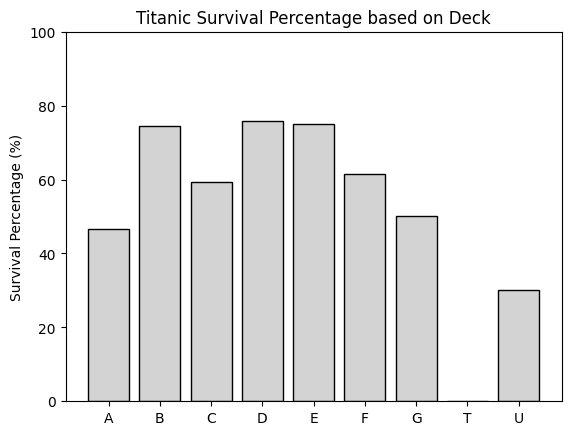

In [51]:
plot_bar_categorical(titanic_data, 'Deck')

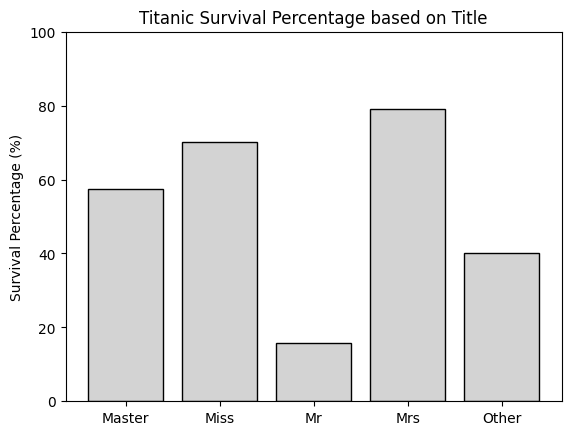

In [52]:
plot_bar_categorical(titanic_data,'Title')

Na podstawie wykresów można zauważyć że:

* Około 38% pasażerów przeżyło.
* Największa przeżywalność występuje w pierwszej klasie podróży.
* Kobiety mają znacznie wyższą przeżywalność niż mężczyźni.
* W przypadku zmiennej 'Title' wysoką przeżywalność można zauważyć u tytułów: Mrs, Miss, Master, które odpowiadają kobietą i chłopcom.
* Największa przeżywalność była na pokładach B, D, E. Na pokładzie T nikt nie przeżył

# Sprawdzenie rozkładu wartości numerycznych:


* Age
* Fare
* SibSp
* Parch





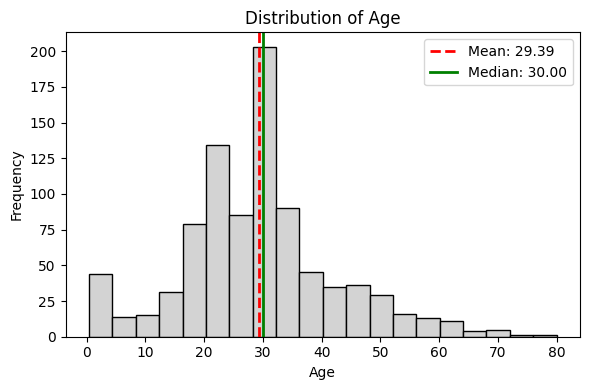

In [53]:
def plot_numeric_histogram(df, column_name):
    data = df[column_name].dropna()
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=20, color='lightgray', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()



def boxplot(df, column_name):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column_name].dropna(), color='lightgray')
    plt.title(f'Distribution of {column_name} (boxplot)')
    plt.xlabel(column_name)
    plt.show()


plot_numeric_histogram(titanic_data, 'Age')

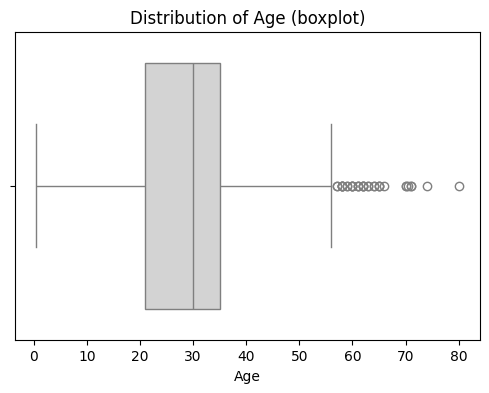

In [54]:
boxplot(titanic_data,'Age')

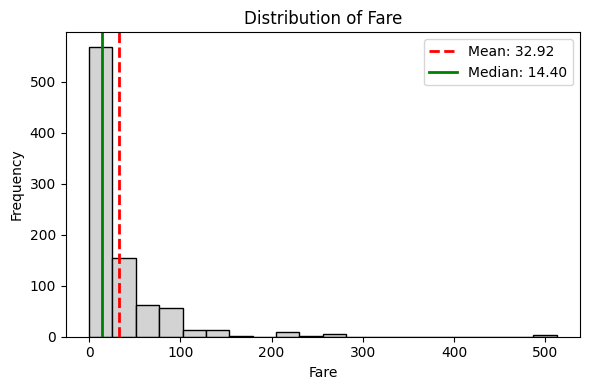

In [55]:
plot_numeric_histogram(titanic_data, 'Fare')

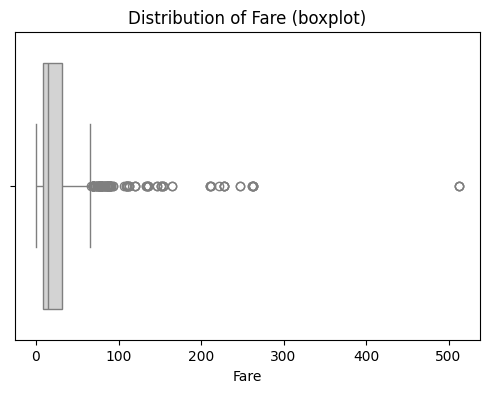

In [56]:
boxplot(titanic_data,'Fare')

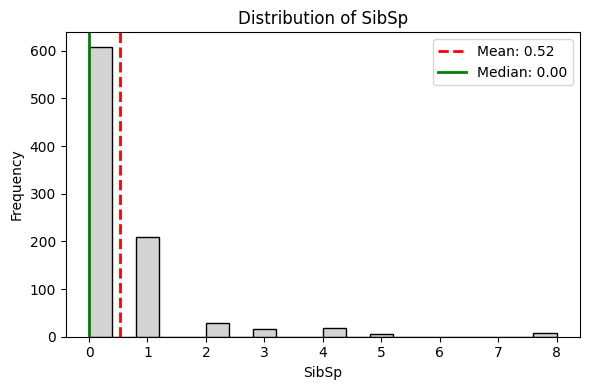

In [57]:
plot_numeric_histogram(titanic_data, 'SibSp')

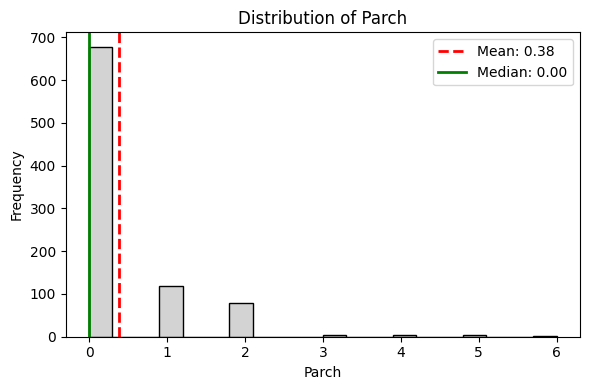

In [58]:
plot_numeric_histogram(titanic_data, 'Parch')

Na podstawie wykresów można zauważyć że:

* Histogram Age wskazuje, że większość pasażerów znajdowała się w wieku dorosłym. Bloxplot pokazuje występowanie wartości odstających po stronie wyższych wartości wieku.

* Histogram Fare wskazuje na rozkład asymetrycznie prawostronny. Większość pasażerów wybrała najtańsze opcje biletowe. Niewielka liczba obserwacji osiąga wysokie wartości.  Równocześnie boxplot potwierdza istnienie  outlier'ów po prawej stronie rozkładu.

* Histogramy SibSp oraz Parch wskazują, że większość pasażerów podróżowała bez dużej liczby członków rodziny na pokładzie. W obu zmiennych dominują niskie wartości.

# Survived w zależności od wartości numerycznych:
* age
* fare

In [59]:
def survival_depending_boxplot(df, column_name):
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[column_name].dropna(), x=df['Survived'], color='lightgray',
                        medianprops={'color': 'red'})
    plt.title(f'Distribution of {column_name} depending on Survival (boxplot)')
    plt.show()

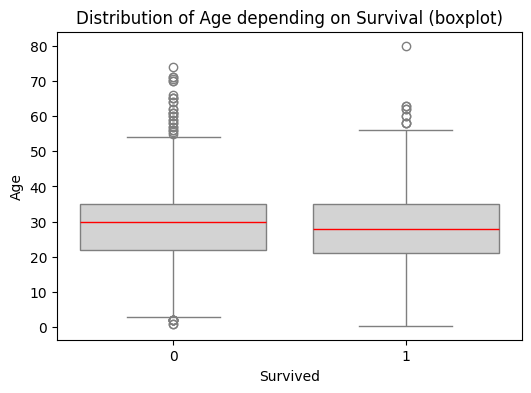

In [60]:
survival_depending_boxplot(titanic_data,'Age')

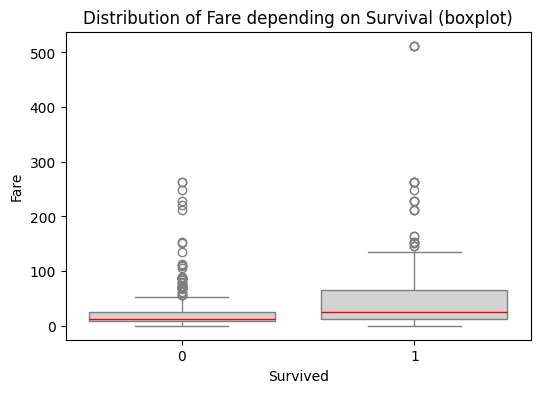

In [61]:
survival_depending_boxplot(titanic_data,'Fare')

Na podstawie wykresów można zauważyć że:

* Rozkłady wieku dla pasażerów, którzy przeżyli i nie przeżyli, są zbliżone.
* Pasażerowie, którzy przeżyli, mają wyższą medianę ceny biletu oraz wyższe wartości kwartylowe. Sugeruje to, że większa szansa przeżycia jest powiązana z ceną biletu.

#Heatmap


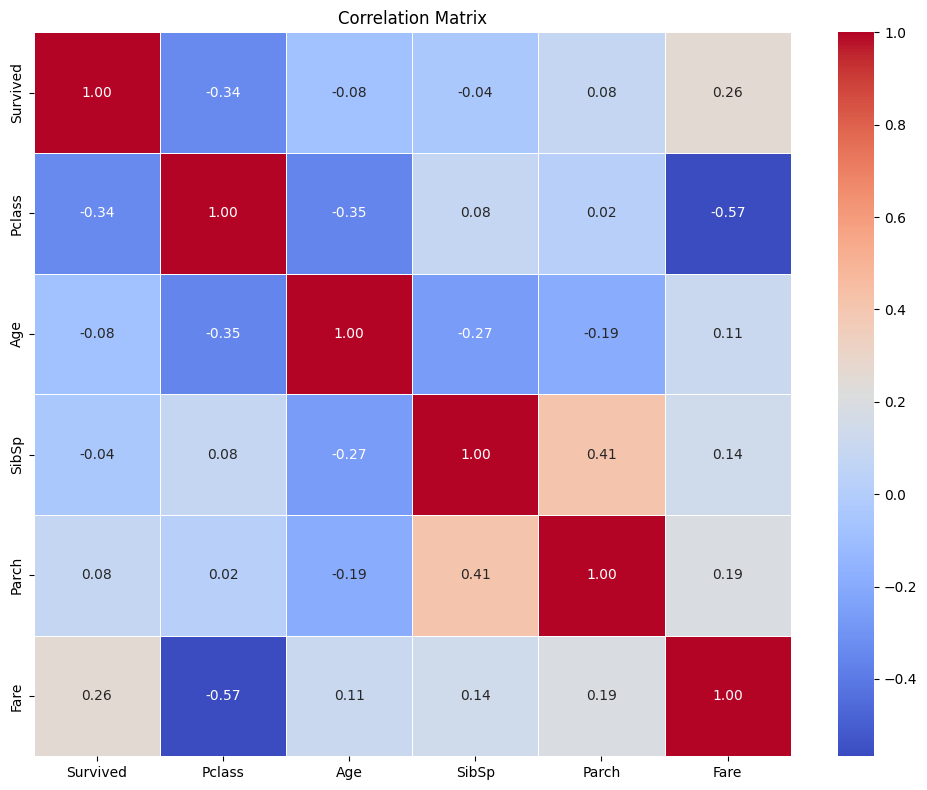

In [62]:
def plot_correlation_matrix(df):
    """
    Plots a heatmap showing the correlation matrix for numeric columns in the DataFrame.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing numeric data.
    Returns:
        None. Displays the correlation heatmap.
    """
    # compute correlation matrix only for numeric columns
    corr = df.corr(numeric_only=True)

    # fmt=".2f" rounds the number to 0.01
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

plot_correlation_matrix(titanic_data)

# Kodowanie wartości kategorialnych

Do kolumn: 'Sex', 'Embarked', 'Title', 'Deck' zastosowano one-hot encoding, ponieważ to zmienne kategorialne, których wartości nie mają naturalnego porządku liczbowego

Kolumna Survived została w jej originalnej formie, ponieważ jest zmienną binarną.

Kolumna Pclass nie została zakodowana za pomocą one-hot encodingu, ponieważ jest zmienną porządkową. Jej wartości reprezentują uporządkowane klasy podróży.

In [63]:
categorical_columns = ['Sex', 'Embarked', 'Title', 'Deck']
titanic_data = pd.get_dummies(titanic_data, columns=categorical_columns, dtype=np.int32)
titanic_data.head(n=5)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,...,Title_Other,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U
0,0,3,22.0,1,0,7.2500,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,1,35.0,1,0,53.1000,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,3,35.0,0,0,8.0500,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


In [64]:
titanic_data.isna().sum().sort_values(ascending=False)

,0
Survived,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0
Sex_female,0
Sex_male,0
Embarked_C,0
Embarked_Q,0
